In [5]:
!apt-get install -y jq
!cp "/content/drive/MyDrive/Colab Notebooks/Data_Distribution.ipynb"
!jq 'del(.metadata.widgets)' "/content/drive/MyDrive/Colab Notebooks/Data_Distribution.ipynb" > "/content/drive/MyDrive/Colab Notebooks/Data_Distribution_fixed.ipynb"


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
jq is already the newest version (1.6-2.1ubuntu3.1).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.
cp: missing destination file operand after '/content/drive/MyDrive/Colab Notebooks/Data_Distribution.ipynb'
Try 'cp --help' for more information.


In [12]:
# ================================================
# Drive mount + force ALL outputs into Drive/"Data Distribution"
# ================================================
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_OUT = "/content/drive/MyDrive/Data Distribution"
os.makedirs(BASE_OUT, exist_ok=True)

# --- scan / intermediates ---
SCAN_OUT_DIR   = BASE_OUT
PICKLE_OUT     = os.path.join(BASE_OUT, "tfrecord_scan_records.pkl")
NPZ_OUT        = os.path.join(BASE_OUT, "tfrecord_scan_arrays.npz")

# --- loc dict / folds / keymap ---
LOC_DICT_PATH  = os.path.join(BASE_OUT, "dhs_loc_dict.pkl")
INC_FOLDS_PATH = os.path.join(BASE_OUT, "dhs_incountry_folds.pkl")
KEYMAP_PKL     = os.path.join(BASE_OUT, "tfrecord_key_to_path.pkl")

# --- combined dataframes ---
OUT_CSV        = os.path.join(BASE_OUT, "dhs_combined_df.csv")
OUT_PQ         = os.path.join(BASE_OUT, "dhs_combined_df.parquet")

# --- figures ---
OUT_PNG_OOC    = os.path.join(BASE_OUT, "africa_ooc_test_folds.png")
OUT_PNG_INC    = os.path.join(BASE_OUT, "africa_incountry_test_folds.png")

def savefig_dd(name_or_path, dpi=200):
    """Save current matplotlib figure into Data Distribution."""
    p = name_or_path
    if not os.path.isabs(p):
        p = os.path.join(BASE_OUT, str(name_or_path))
    os.makedirs(os.path.dirname(p), exist_ok=True)
    import matplotlib.pyplot as plt
    plt.tight_layout()
    plt.savefig(p, dpi=dpi)
    print("Saved figure:", p)

print("Will save everything to:", BASE_OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Will save everything to: /content/drive/MyDrive/Data Distribution


In [13]:
from google.colab import auth
auth.authenticate_user()
!gcloud config set project master-thesis-measles -q


INFORMATION: Project 'master-thesis-measles' has no 'environment' tag set. Use either 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`.
Updated property [core/project].


In [14]:
# ================================================
# 1) Imports and Constants
# ================================================
import os, re, math, glob, io, sys, pickle, json, random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
os.environ['CUDA_VISIBLE_DEVICES'] = ''  # force CPU here

# -------- CONFIG: paths --------
GCS_PREFIX      = "gs://ssadata"              # change if needed
TFRECORD_GLOB   = f"{GCS_PREFIX}/*_*.tfrecord.gz"  # e.g., BF_2021_00.tfrecord.gz
LOC_WEALTH_CSV  = "/content/drive/My Drive/Master_Thesis/Surveys/clusters_yeh_spec.csv"

# -------- CONFIG: imagery + labels --------
PATCH           = 255             # exported patch size
CROP            = 224             # center crop to 224x224
PIXELS          = CROP * CROP
SCALE_M         = 30              # meters/pixel for Landsat
BANDS_MS        = ["BLUE","GREEN","RED","NIR","SWIR1","SWIR2","TEMP1"]
BANDS_ALL       = BANDS_MS + ["NIGHTLIGHTS"]  # LON/LAT are metadata arrays if present
BAND_ORDER      = ["BLUE","GREEN","RED","SWIR1","SWIR2","TEMP1","NIR","NIGHTLIGHTS"]
DATASET_TAG     = "custom-DRC-spec"

FOLDS           = ['A','B','C','D','E']
SPLITS          = ['train','val','test']

# DMSP vs VIIRS split threshold
DMSP_VIIRS_YEAR = 2012  # DMSP < 2012, VIIRS >= 2012

# TEMP1 DN→Kelvin heuristic if needed
ST10_SCALE  = 0.00341802
ST10_OFFSET = 149.0

rng = np.random.default_rng(42)


In [ ]:
# ================================================
# 2) Load data (scan TFRecords → arrays + meta)
# With progress bars and automatic saving
# ================================================
from tqdm.auto import tqdm

def _as_arr(f, k):
    return np.asarray(f[k].float_list.value, dtype=np.float32) if k in f else None

def _as_int(f, k):
    if k in f and f[k].int64_list.value:
        return int(f[k].int64_list.value[0])
    if k in f and f[k].float_list.value:
        return int(f[k].float_list.value[0])
    return None

def _as_str(f, k):
    if k in f and f[k].bytes_list.value:
        return f[k].bytes_list.value[0].decode("utf-8")
    return None

def _center_crop(arr, patch=PATCH, crop=CROP):
    if arr is None or arr.size != patch * patch:
        return None
    z = arr.reshape(patch, patch)
    s = (patch - crop) // 2
    return z[s:s+crop, s:s+crop].ravel()

def _nl_center_mean(nl_arr):
    if nl_arr is None or nl_arr.size != PATCH * PATCH:
        return np.nan, np.nan
    z = nl_arr.reshape(PATCH, PATCH)
    s = (PATCH - CROP) // 2
    zc = z[s:s+CROP, s:s+CROP]
    return float(z[PATCH//2, PATCH//2]), float(zc.mean())

def iter_examples_tfrecord(tfrecord_path):
    ds = tf.data.TFRecordDataset(tfrecord_path, compression_type="GZIP")
    for raw in ds.as_numpy_iterator():
        yield tf.train.Example.FromString(raw)

def list_tfrecord_paths():
    return sorted(tf.io.gfile.glob(TFRECORD_GLOB))

# ---------- Scan with progress ----------
records = []
paths = list_tfrecord_paths()
assert len(paths) > 0, f"No TFRecords found at {TFRECORD_GLOB}"

for p in tqdm(paths, desc="TFRecord files"):
    try:
        examples = list(iter_examples_tfrecord(p))
    except Exception as e:
        print(f"Error reading {p}: {e}")
        continue
    for ex in tqdm(examples, desc=os.path.basename(p), leave=False):
        f = ex.features.feature
        country = _as_str(f, "country")
        year    = _as_int(f, "year")
        cluster = _as_int(f, "cluster_index") if "cluster_index" in f else _as_int(f, "cluster")

        band_arrays = {b: _as_arr(f, b) for b in BANDS_ALL}
        nl_center, nl_mean = _nl_center_mean(band_arrays.get("NIGHTLIGHTS"))

        records.append({
            "country": country,
            "year": year,
            "cluster": cluster,
            "nls_center": nl_center,
            "nls_mean": nl_mean,
        })

# --- Convert to arrays ---
years      = np.asarray([r["year"] for r in records], dtype=np.int32)
nls_center = np.asarray([r["nls_center"] for r in records], dtype=np.float32)
nls_mean   = np.asarray([r["nls_mean"] for r in records], dtype=np.float32)

# --- Save outputs to Drive ---
with tf.io.gfile.GFile(PICKLE_OUT, "wb") as f:
    pickle.dump(records, f)
np.savez_compressed(NPZ_OUT,
                    years=years,
                    nls_center=nls_center,
                    nls_mean=nls_mean)

print(f"TF examples: {len(records)} from {len(paths)} files")
print(f"Saved:\n - Pickle: {PICKLE_OUT}\n - NPZ: {NPZ_OUT}")


In [16]:
# ================================================
# 2.1) Build collision-free loc_dict keyed by (COUNTRY_2L, YEAR, CLUSTER)
# ================================================
df = pd.read_csv(LOC_WEALTH_CSV, float_precision="high")
need = {"country","year","cluster","wealthpooled","lat","lon","n_households","urban"}
miss = need - set(df.columns)
if miss: raise ValueError(f"CSV missing columns: {sorted(miss)}")

df["country"] = df["country"].astype(str).str.upper().str[:2]
df["year"]    = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["cluster"] = pd.to_numeric(df["cluster"], errors="coerce").astype("Int64")

df["wealthpooled"] = pd.to_numeric(df["wealthpooled"], errors="coerce").astype(float)
df["lat"]          = pd.to_numeric(df["lat"], errors="coerce").astype(float)
df["lon"]          = pd.to_numeric(df["lon"], errors="coerce").astype(float)
df["n_households"] = pd.to_numeric(df["n_households"], errors="coerce").fillna(0).astype(int)

if df["urban"].dtype == object:
    df["urban"] = (df["urban"].astype(str).str.upper() == "U")
else:
    df["urban"] = (pd.to_numeric(df["urban"], errors="coerce").fillna(0).astype(int) == 1)

if "svyid" in df.columns:
    df["svyid_year"] = df["svyid"].astype(str).str[-4:].astype(int)
else:
    df["svyid_year"] = df["year"].astype(int)

df_id = df.dropna(subset=["country","year","cluster","lat","lon"]).copy()
dupes = df_id.duplicated(subset=["country","year","cluster"], keep=False)
if dupes.any():
    n_dupe_rows = int(dupes.sum())
    n_dupe_keys = int(df_id.loc[dupes, ["country","year","cluster"]].drop_duplicates().shape[0])
    print(f"WARNING: duplicate (country,year,cluster) rows: {n_dupe_rows} across {n_dupe_keys}. Keeping first.")
df_id = df_id.drop_duplicates(subset=["country","year","cluster"], keep="first")

loc_dict = {}
for _, r in df_id.iterrows():
    key = (str(r["country"]), int(r["year"]), int(r["cluster"]))
    loc_dict[key] = {
        "lat":          float(r["lat"]),
        "lon":          float(r["lon"]),
        "country":      str(r["country"]),
        "year":         int(r["year"]),
        "cluster":      int(r["cluster"]),
        "country_year": f"{str(r['country'])}_{int(r['svyid_year'])}",
        "svyid_year":   int(r["svyid_year"]),
        "households":   int(r["n_households"]),
        "urban":        bool(r["urban"]),
        "wealthpooled": float(r["wealthpooled"]),
    }

with tf.io.gfile.GFile(LOC_DICT_PATH, "wb") as f:
    pickle.dump(loc_dict, f)

print(f"loc_dict entries (identifier-keyed): {len(loc_dict)}")
print("Saved:", LOC_DICT_PATH)


loc_dict entries (identifier-keyed): 15992
Saved: /content/drive/MyDrive/Data Distribution/dhs_loc_dict.pkl


In [31]:
# ================================================
# 2.2) Combine to one DataFrame by (country, year, cluster)
# ================================================
with tf.io.gfile.GFile(PICKLE_OUT, "rb") as f:
    records = pickle.load(f)
npz = np.load(NPZ_OUT)
nls_center = np.asarray(npz["nls_center"], dtype=np.float32)
nls_mean   = np.asarray(npz["nls_mean"],   dtype=np.float32)

tf_df = pd.DataFrame(records)
need_cols = {"country","year","cluster"}
if not need_cols.issubset(tf_df.columns):
    raise ValueError(f"{PICKLE_OUT} missing columns: {sorted(need_cols - set(tf_df.columns))}")

N = len(tf_df)
if not (len(nls_center) == len(nls_mean) == N):
    raise AssertionError("NPZ arrays not aligned with records length")

tf_df["country"] = tf_df["country"].astype(str).str.upper().str[:2]
tf_df["year"]    = pd.to_numeric(tf_df["year"], errors="coerce").astype(int)
tf_df["cluster"] = pd.to_numeric(tf_df["cluster"], errors="coerce").astype(int)
tf_df["row_id"]  = np.arange(N, dtype=np.int64)
tf_df["key"]     = list(zip(tf_df["country"], tf_df["year"], tf_df["cluster"]))
tf_df["nl_center"] = nls_center
tf_df["nl_mean"]   = nls_mean

with tf.io.gfile.GFile(LOC_DICT_PATH, "rb") as f:
    loc_dict2 = pickle.load(f)

ldf = pd.DataFrame(
    [{"country":k[0], "year":k[1], "cluster":k[2], **v} for k, v in loc_dict2.items()]
)
ldf["country"] = ldf["country"].astype(str).str.upper().str[:2]
ldf["year"]    = pd.to_numeric(ldf["year"], errors="coerce").astype(int)
ldf["cluster"] = pd.to_numeric(ldf["cluster"], errors="coerce").astype(int)
ldf["key"]     = list(zip(ldf["country"], ldf["year"], ldf["cluster"]))

merged = tf_df.merge(ldf[["key","lat","lon","urban","households","wealthpooled","svyid_year","country_year"]],
                     on="key", how="left", validate="one_to_one")

if merged["lat"].isna().any():
    missing = int(merged["lat"].isna().sum())
    raise AssertionError(f"{missing} TF examples had no match in loc_dict by (country,year,cluster)")

year_for_df = pd.to_numeric(merged["svyid_year"], errors="coerce").astype(int)
urban01 = merged["urban"].astype(int)

df = pd.DataFrame({
    "lat":          merged["lat"].astype(float),
    "lon":          merged["lon"].astype(float),
    "wealthpooled": merged["wealthpooled"].astype(float),
    "country":      merged["country"].astype(str),
    "year":         year_for_df.astype(int),
    "urban":        urban01,                     # 0/1
    "nl_mean":      merged["nl_mean"].astype(float),
    "nl_center":    merged["nl_center"].astype(float),
    "households":   merged["households"].astype(int),
})

with pd.option_context("display.max_rows", 10):
    display(df)

print(f"Combined rows: {len(df)} "
      f"| distinct (country,year,cluster): {merged[['country','year','cluster']].drop_duplicates().shape[0]}")

df.to_csv(OUT_CSV, index=False)
df.to_parquet(OUT_PQ, index=False)
print("Saved:")
print(" - CSV:", OUT_CSV)
print(" - Parquet:", OUT_PQ)

# convenience for later cells
LOCS = df[["lat","lon"]].to_numpy(dtype=float)


,lat,lon,wealthpooled,country,year,urban,nl_mean,nl_center,households
0,13.102978,-4.228226,-0.765235,BF,2021,0,0.314703,0.305,26
1,12.598484,-4.173245,-0.805675,BF,2021,0,0.300477,0.305,26
2,12.763744,-4.105527,-0.469937,BF,2021,0,0.299975,0.300,25
3,12.621010,-3.814051,-1.231751,BF,2021,0,0.290770,0.290,26
4,12.862176,-3.918574,-1.042536,BF,2021,0,0.293274,0.290,26
...,...,...,...,...,...,...,...,...,...
15987,-15.273393,27.762883,-0.348080,ZM,2019,0,0.244575,0.200,25
15988,-16.517928,26.996115,-0.504412,ZM,2019,0,0.174679,0.155,21
15989,-13.754989,32.596230,-0.572812,ZM,2019,0,0.208598,0.210,23
15990,-13.645926,32.649326,1.766822,ZM,2019,1,6.128901,11.795,20


Combined rows: 15992 | distinct (country,year,cluster): 15992
Saved:
 - CSV: /content/drive/MyDrive/Data Distribution/dhs_combined_df.csv
 - Parquet: /content/drive/MyDrive/Data Distribution/dhs_combined_df.parquet


Lat. min: -30.533212, max: 25.422785
Lon. min: -17.485937, max: 50.360668
maximum side_lat: 0.060570
maximum side_lon: 0.070321
Saved figure: /content/drive/MyDrive/Data Distribution/locs_hist_lat_lon.png


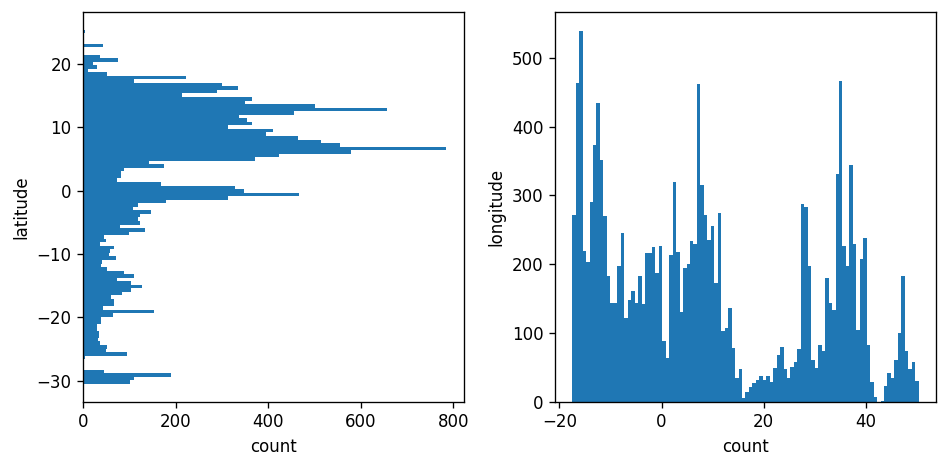

In [18]:
# ================================================
# 3) Locations — stats + hist
# ================================================
RADIUS_EARTH = 6356.7523  # km, polar radius

def get_lon_for_distance(lat, d_km):
    lat_r = np.abs(lat) * np.pi / 180.0
    r = RADIUS_EARTH * np.cos(lat_r)
    lon = d_km / r
    return lon * 180.0 / np.pi

def get_lat_for_distance(d_km):
    lat = d_km / RADIUS_EARTH
    return lat * 180.0 / np.pi

def print_loc_stats(locs):
    min_lat, min_lon = np.min(locs, axis=0)
    max_lat, max_lon = np.max(locs, axis=0)
    print(f'Lat. min: {min_lat:.6f}, max: {max_lat:.6f}')
    print(f'Lon. min: {min_lon:.6f}, max: {max_lon:.6f}')
    side_km = CROP * SCALE_M / 1000.0
    far_lat = max(abs(min_lat), abs(max_lat))
    side_lat = get_lat_for_distance(side_km)
    side_lon = get_lon_for_distance(far_lat, side_km)
    print(f'maximum side_lat: {side_lat:.6f}')
    print(f'maximum side_lon: {side_lon:.6f}')

def plot_locs_histogram(locs):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[8, 4])
    axs[0].hist(locs[:, 0], bins=100, orientation='horizontal')
    axs[0].set(xlabel='count', ylabel='latitude')
    axs[1].hist(locs[:, 1], bins=100, orientation='vertical')
    axs[1].set(xlabel='count', ylabel='longitude')
    savefig_dd("locs_hist_lat_lon.png")
    fig.tight_layout(); plt.show()

print_loc_stats(LOCS)
plot_locs_histogram(LOCS)


In [19]:
# ================================================
# 4) Create Data Splits
# 4.1) country_indices and country_labels
# ================================================
COUNTRIES = np.array(sorted(df['country'].unique()))
country_indices = defaultdict(list)
country_labels  = np.zeros(len(df), dtype=np.int32)

for i in range(len(df)):
    country_indices[df['country'].iloc[i]].append(i)

for i, country in enumerate(COUNTRIES):
    idxs = np.asarray(country_indices[country], dtype=np.int64)
    country_indices[country] = idxs
    country_labels[idxs] = i


{'A': {'test': 4838, 'train': 7824, 'val': 3330},
 'B': {'test': 3330, 'train': 9862, 'val': 2800},
 'C': {'test': 2800, 'train': 10430, 'val': 2762},
 'D': {'test': 2762, 'train': 10968, 'val': 2262},
 'E': {'test': 2262, 'train': 8892, 'val': 4838}}
Saved figure: /content/drive/MyDrive/Data Distribution/africa_ooc_test_folds.png


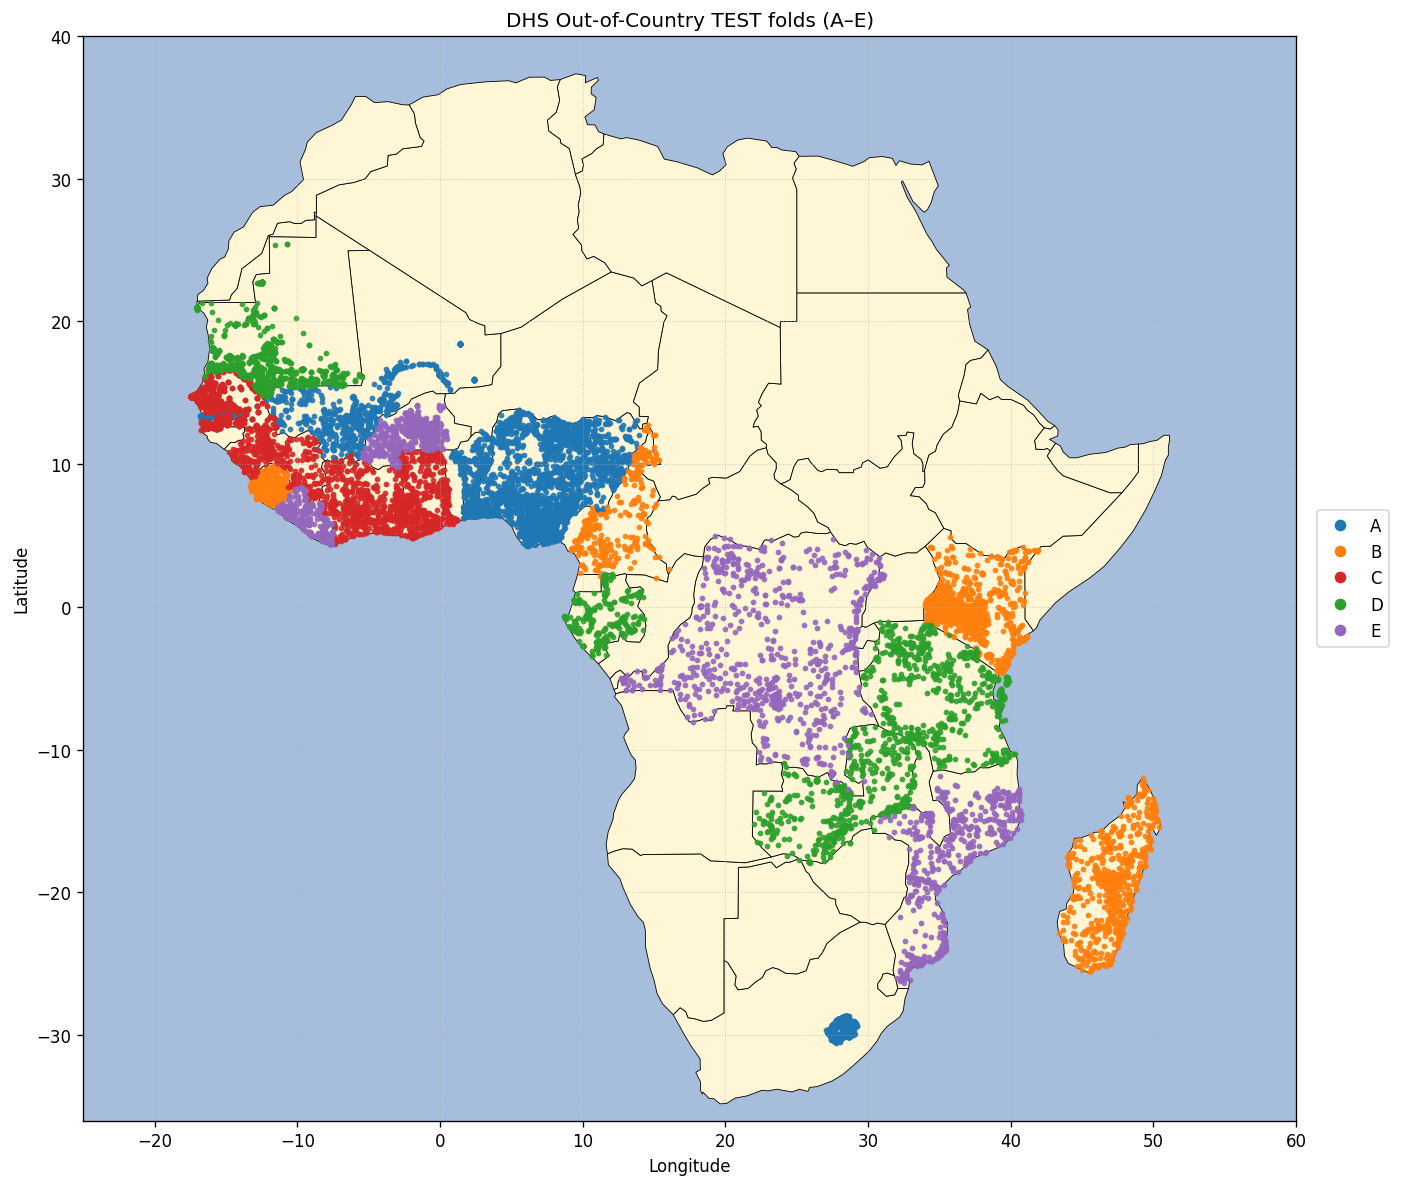

In [20]:
# ================================================
# 4.2) OOC splits (balanced by country across 5 folds) + Africa map of TEST folds
# ================================================
from pprint import pprint

def make_ooc_folds_balanced(country_indices, folds=FOLDS):
    order = sorted(country_indices.items(), key=lambda kv: len(kv[1]), reverse=True)
    fold_countries = {f: [] for f in folds}
    for i, (cc, _) in enumerate(order):
        fold_countries[folds[i % len(folds)]].append(cc)

    ooc = {f: {s: None for s in SPLITS} for f in folds}
    for f in folds:
        test_countries  = fold_countries[f]
        val_countries   = fold_countries[folds[(folds.index(f)+1) % len(folds)]]
        train_countries = [c for c in COUNTRIES if c not in set(test_countries + val_countries)]
        ooc[f]['test']  = np.sort(np.concatenate([country_indices[c] for c in test_countries]))  if test_countries  else np.array([], dtype=int)
        ooc[f]['val']   = np.sort(np.concatenate([country_indices[c] for c in val_countries]))   if val_countries   else np.array([], dtype=int)
        ooc[f]['train'] = np.sort(np.concatenate([country_indices[c] for c in train_countries])) if train_countries else np.array([], dtype=int)
    return ooc

ooc_folds = make_ooc_folds_balanced(country_indices)
pprint({f:{s:len(ooc_folds[f][s]) for s in SPLITS} for f in FOLDS})

!pip -q install geopandas shapely pyproj
import geopandas as gpd
from matplotlib.lines import Line2D

NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world  = gpd.read_file(NE_URL)
africa = world[world["CONTINENT"] == "Africa"].to_crs("EPSG:4326")

FOLD_COLORS = {"A":"#1f77b4","B":"#ff7f0e","C":"#d62728","D":"#2ca02c","E":"#9467bd"}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#a6bddb")
africa.plot(ax=ax, color="#fff6d5", edgecolor="black", linewidth=0.5)

for f in FOLDS:
    idx = ooc_folds[f]["test"].astype(int)
    valid = (idx >= 0) & (idx < len(LOCS))
    idx = idx[valid]
    if idx.size == 0:
        continue
    ax.scatter(LOCS[idx, 1], LOCS[idx, 0], s=6, c=FOLD_COLORS[f], label=f, alpha=0.85)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=FOLD_COLORS[f],
                  markersize=8, linestyle='') for f in FOLDS]
ax.legend(handles, FOLDS, title="", loc="center left", bbox_to_anchor=(1.01, 0.5))

ax.set_xlim(-25, 55); ax.set_ylim(-36, 38)
ax.set_xticks(np.arange(-20, 61, 10)); ax.set_yticks(np.arange(-30, 41, 10))
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("DHS Out-of-Country TEST folds (A–E)")

savefig_dd(OUT_PNG_OOC)
plt.show()


num clusters: 1686
max cluster size: 465
num outliers: 4534
Saved: /content/drive/MyDrive/Data Distribution/dhs_incountry_folds.pkl
{'A': {'test': 3199, 'train': 9594, 'val': 3199},
 'B': {'test': 3199, 'train': 9595, 'val': 3198},
 'C': {'test': 3198, 'train': 9596, 'val': 3198},
 'D': {'test': 3198, 'train': 9596, 'val': 3198},
 'E': {'test': 3198, 'train': 9595, 'val': 3199}}
incountry MIN_DIST deg: 0.09281024778521978
Saved figure: /content/drive/MyDrive/Data Distribution/africa_incountry_test_folds.png


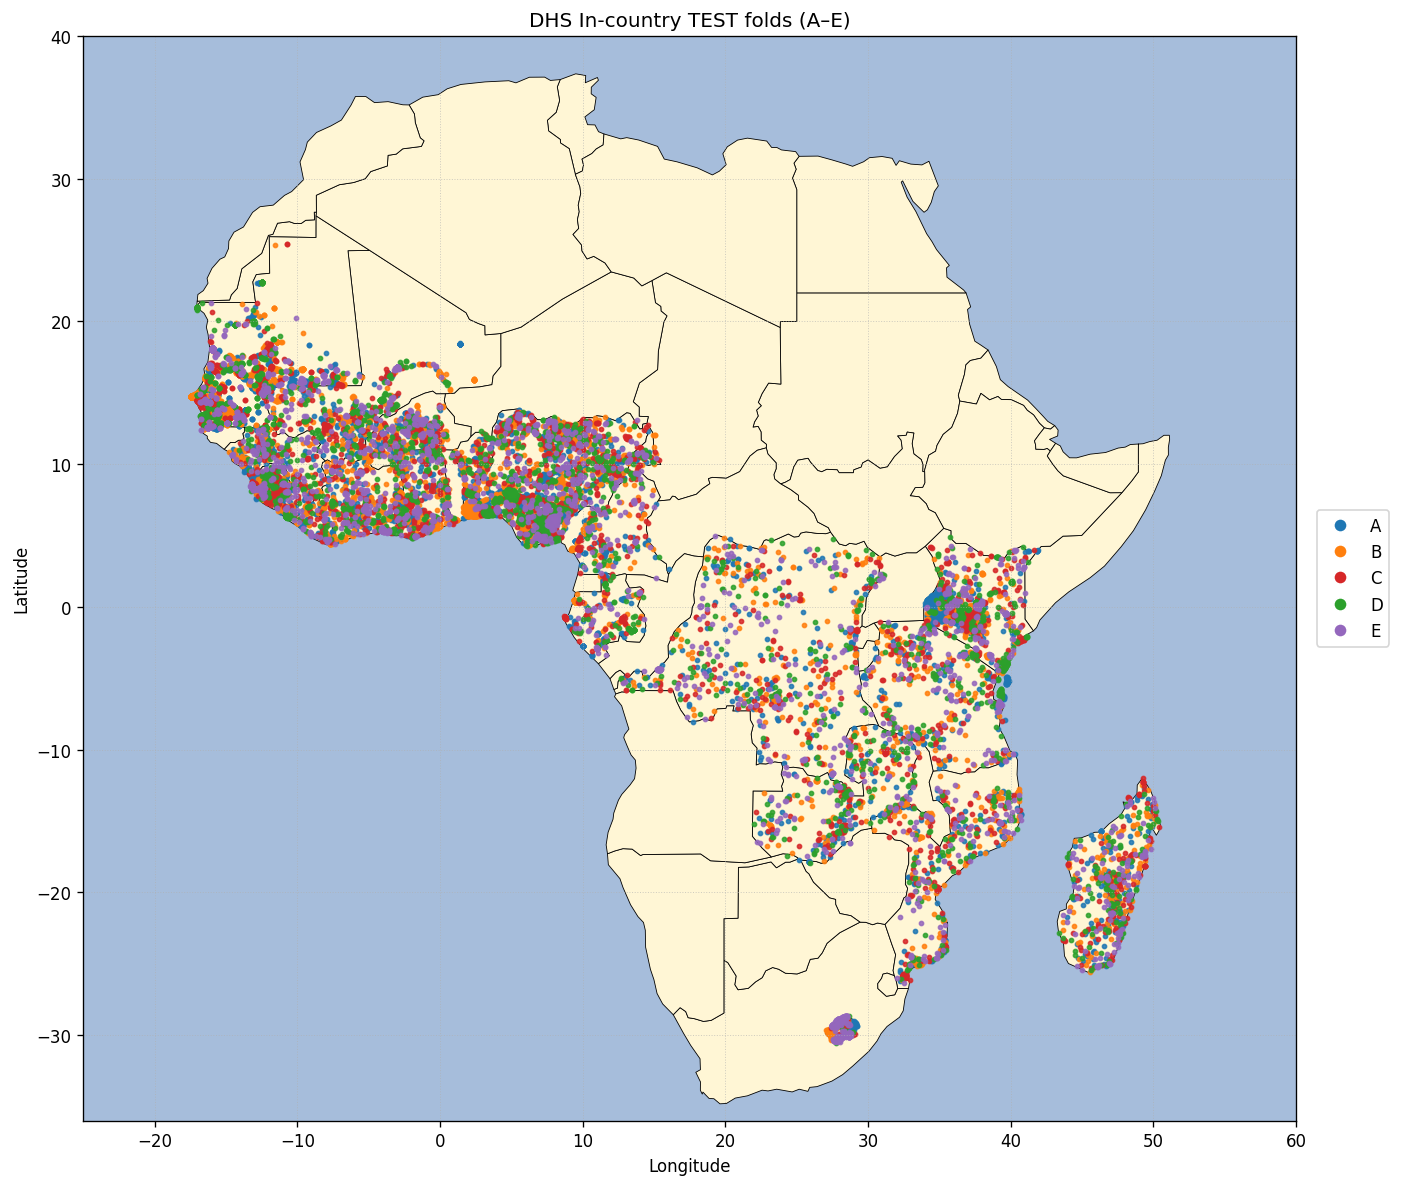

In [22]:
import math, pickle
from matplotlib.lines import Line2D
!pip -q install geopandas shapely pyproj
import geopandas as gpd
from collections import defaultdict
import itertools, scipy.spatial
from sklearn.cluster import dbscan as _dbscan

RADIUS_EARTH = 6356.7523  # km, polar radius
def get_lat_for_distance_km(d):
    return (d / RADIUS_EARTH) * 180.0 / np.pi
def get_lon_for_distance_km(lat_deg, d):
    r = RADIUS_EARTH * np.cos(np.abs(lat_deg) * np.pi / 180.0)
    return (d / r) * 180.0 / np.pi

def create_folds(locs, min_dist, dist_metric, fold_names, verbose=True, plot_largest_clusters=0):
    locs = np.asarray(locs, dtype=float)
    locs_to_indices = defaultdict(list)
    for i, loc in enumerate(locs):
        locs_to_indices[tuple(loc)].append(i)
    uniq = np.unique(locs, axis=0)
    _, labels = _dbscan(X=uniq, eps=min_dist, min_samples=2, metric=dist_metric)

    clusters = defaultdict(list)
    neg = -1
    for u, c in zip(uniq, labels):
        idxs = locs_to_indices[tuple(u)]
        if c < 0:
            c = neg
            neg -= 1
        clusters[c].extend(idxs)

    ordered = sorted(clusters.keys(), key=lambda c: -len(clusters[c]))
    fold_countries = {f: [] for f in fold_names}
    for c in ordered:
        f = min(fold_countries, key=lambda k: len(fold_countries[k]))
        fold_countries[f].extend(clusters[c])
    for f in fold_countries:
        fold_countries[f] = np.sort(np.asarray(fold_countries[f], dtype=np.int64))
    if verbose:
        sizes = [len(clusters[c]) for c in ordered if c >= 0]
        print("num clusters:", sum(1 for c in clusters if c >= 0))
        print("max cluster size:", max(sizes) if sizes else 1)
        print("num outliers:", sum(1 for c in clusters if c < 0))
    return fold_countries

def verify_folds(folds, locs, min_dist, dist_metric, max_index=None):
    for f, idxs in folds.items():
        assert np.all(np.diff(idxs) >= 0)
    if max_index is not None:
        all_idx = np.sort(np.concatenate(list(folds.values())))
        assert np.array_equal(all_idx, np.arange(max_index))
    for a, b in itertools.combinations(folds.keys(), 2):
        da = locs[folds[a]]
        db = locs[folds[b]]
        d = scipy.spatial.distance.cdist(da, db, metric=dist_metric)
        assert np.min(d) > min_dist

side_km = 224 * 30 / 1000.0
far_lat = float(max(abs(LOCS[:,0].min()), abs(LOCS[:,0].max())))
side_lat = get_lat_for_distance_km(side_km)
side_lon = get_lon_for_distance_km(far_lat, side_km)
MIN_DIST = float(math.hypot(side_lat, side_lon))
DIST_METRIC = "euclidean"

test_folds = create_folds(LOCS, min_dist=MIN_DIST, dist_metric=DIST_METRIC, fold_names=FOLDS, verbose=True)
verify_folds(test_folds, locs=LOCS, min_dist=MIN_DIST, dist_metric=DIST_METRIC, max_index=len(LOCS))

incountry_folds = {}
for i, f in enumerate(FOLDS):
    incountry_folds[f] = {}
    incountry_folds[f]['test'] = np.asarray(test_folds[f], dtype=np.int64)
    val_f = FOLDS[(i+1) % len(FOLDS)]
    incountry_folds[f]['val'] = np.asarray(test_folds[val_f], dtype=np.int64)
    train_fs = [FOLDS[(i+2)%5], FOLDS[(i+3)%5], FOLDS[(i+4)%5]]
    incountry_folds[f]['train'] = np.sort(
        np.concatenate([np.asarray(test_folds[x], dtype=np.int64) for x in train_fs])
    )

with tf.io.gfile.GFile(INC_FOLDS_PATH, "wb") as f:
    pickle.dump(incountry_folds, f)
print("Saved:", INC_FOLDS_PATH)

from pprint import pprint
pprint({f: {s: len(incountry_folds[f][s]) for s in ['test','val','train']} for f in FOLDS})
print("incountry MIN_DIST deg:", MIN_DIST)

NE_URL = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world  = gpd.read_file(NE_URL)
africa = world[world["CONTINENT"] == "Africa"].to_crs("EPSG:4326")

FOLD_COLORS = {"A":"#1f77b4","B":"#ff7f0e","C":"#d62728","D":"#2ca02c","E":"#9467bd"}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#a6bddb")
africa.plot(ax=ax, color="#fff6d5", edgecolor="black", linewidth=0.5)

for f in FOLDS:
    idx = incountry_folds[f]["test"]
    if idx.size == 0:
        continue
    ax.scatter(LOCS[idx, 1], LOCS[idx, 0], s=6, c=FOLD_COLORS[f], label=f, alpha=0.85)

handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=FOLD_COLORS[f],
                  markersize=8, linestyle='') for f in FOLDS]
ax.legend(handles, FOLDS, loc="center left", bbox_to_anchor=(1.01, 0.5))

ax.set_xlim(-25, 55); ax.set_ylim(-36, 38)
ax.set_xticks(np.arange(-20, 61, 10)); ax.set_yticks(np.arange(-30, 41, 10))
ax.grid(True, linestyle=':', linewidth=0.6, alpha=0.6)
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("DHS In-country TEST folds (A–E)")

savefig_dd(OUT_PNG_INC)
plt.show()

In [23]:
# ================================================
# 4.4) Urban v. Rural counts by OOC folds
# ================================================
urban_mask = (df['urban'].values.astype(int) == 1)
rural_mask = ~urban_mask

def fold_ur_counts(folds):
    u, r = {}, {}
    for f, splits in folds.items():
        u[f], r[f] = {}, {}
        for s, idx in splits.items():
            idx = np.asarray(idx, dtype=np.int64)
            u[f][s] = int(urban_mask[idx].sum())
            r[f][s] = int(rural_mask[idx].sum())
        u[f]['all'] = sum(u[f][s] for s in SPLITS)
        r[f]['all'] = sum(r[f][s] for s in SPLITS)
    return u, r

uA, rA = fold_ur_counts(ooc_folds)
from pprint import pprint
print("urban counts"); pprint(uA)
print("rural counts"); pprint(rA)


urban counts
{'A': {'all': 6612, 'test': 2085, 'train': 3249, 'val': 1278},
 'B': {'all': 6612, 'test': 1278, 'train': 4087, 'val': 1247},
 'C': {'all': 6612, 'test': 1247, 'train': 4143, 'val': 1222},
 'D': {'all': 6612, 'test': 1222, 'train': 4610, 'val': 780},
 'E': {'all': 6612, 'test': 780, 'train': 3747, 'val': 2085}}
rural counts
{'A': {'all': 9380, 'test': 2753, 'train': 4575, 'val': 2052},
 'B': {'all': 9380, 'test': 2052, 'train': 5775, 'val': 1553},
 'C': {'all': 9380, 'test': 1553, 'train': 6287, 'val': 1540},
 'D': {'all': 9380, 'test': 1540, 'train': 6358, 'val': 1482},
 'E': {'all': 9380, 'test': 1482, 'train': 5145, 'val': 2753}}


Saved figure: /content/drive/MyDrive/Data Distribution/countries_by_size.png


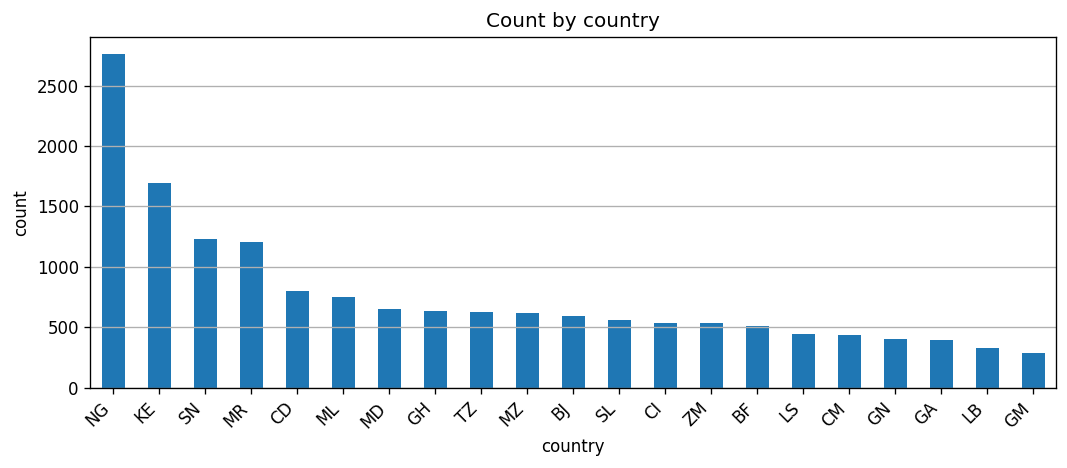

count
country year       
BF      2021    514
BJ      2017    288
        2018    309
CD      2023    617
        2024    179
CI      2021    539
CM      2018    427
        2019      5
GA      2019     34
        2020    166
        2021    192
GH      2022    549
        2023     84
GM      2019     87
        2020    197
GN      2018    401
KE      2022   1691
LB      2019    187
        2020    143
LS      2023    110
        2024    333
MD      2021    650
ML      2018    328
        2023    114
        2024    308
MR      2019    293
        2020    730
        2021    180
MZ      2022    523
        2023     99
NG      2018   1382
        2023    173
        2024   1209
SL      2019    557
SN      2017    400
        2018    214
        2019    214
        2023    399
TZ      2022    628
ZM      2018    522
        2019     17

In [24]:
# ================================================
# 5.1) Size
# ================================================
def plot_countries_by_size(df):
    counts = df.groupby('country').size().sort_values(ascending=False)
    fig, ax = plt.subplots(1,1, figsize=(9,4))
    counts.plot(kind='bar', ax=ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_ylabel('count'); ax.set_title('Count by country'); ax.grid(True, axis='y')
    savefig_dd("countries_by_size.png")
    plt.show()

plot_countries_by_size(df)

with pd.option_context('display.max_rows', 200):
    display(df.groupby(['country','year']).size().rename('count').to_frame())


,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
BF,514.0,0.004042,0.736387,-1.231751,-0.561926,-0.184110,0.418515,3.031259
BJ,597.0,0.020657,0.740291,-1.261835,-0.557607,-0.180859,0.549650,2.448210
CD,796.0,-0.002704,0.855725,-0.809626,-0.462135,-0.327432,0.009635,3.747965
CI,539.0,0.010858,0.739989,-1.603834,-0.551072,0.000939,0.587728,2.019389
CM,432.0,0.000361,0.800773,-1.630068,-0.781650,0.140148,0.669901,1.691910
GA,392.0,0.001144,0.816616,-1.916151,-0.605175,0.326553,0.630460,1.290999
GH,633.0,-0.006255,0.741727,-1.609941,-0.474917,0.012504,0.522125,1.852116
GM,284.0,0.028004,0.787996,-1.533122,-0.813340,0.255652,0.708945,1.442165
GN,401.0,0.004305,0.858723,-1.242448,-0.682460,-0.376428,0.798123,1.996090


Saved figure: /content/drive/MyDrive/Data Distribution/wealthpooled_by_country.png


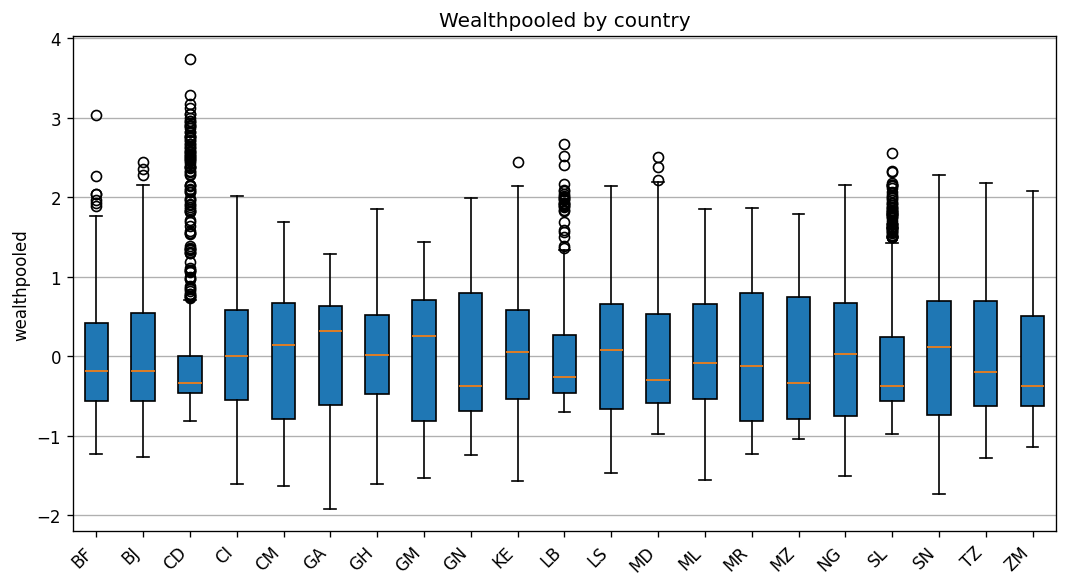

Saved figure: /content/drive/MyDrive/Data Distribution/wealthpooled_by_year.png


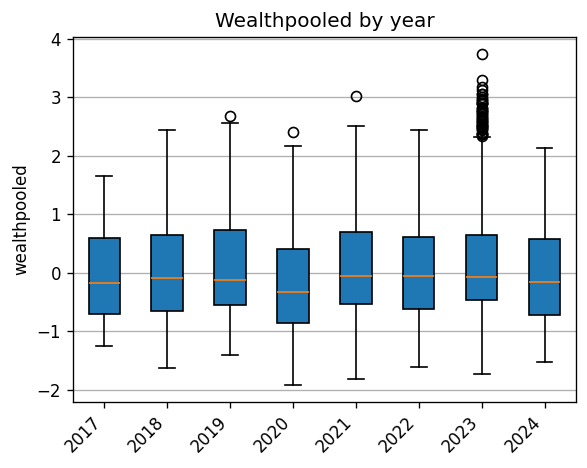

In [25]:
# ================================================
# 5.2) Wealthpooled summary + boxplots
# ================================================
display(df.groupby('country')['wealthpooled'].describe())

def boxplot_df(df_in, y, by, fig_name, figsize=(8,5), ylabel='', title=''):
    data = df_in.groupby(by)[y].apply(list)
    labels = data.index if isinstance(data.index, pd.Index) else range(len(data))
    fig, ax = plt.subplots(1,1, figsize=figsize)
    ax.boxplot(list(data), patch_artist=True)
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel(ylabel or y); ax.set_title(title); ax.grid(True, axis='y')
    savefig_dd(fig_name)
    plt.show()

YEARS = sorted(df['year'].unique())
boxplot_df(df, 'wealthpooled', 'country',
           fig_name="wealthpooled_by_country.png",
           figsize=(9,5), ylabel='wealthpooled', title='Wealthpooled by country')

boxplot_df(df, 'wealthpooled', 'year',
           fig_name="wealthpooled_by_year.png",
           figsize=(5,4), ylabel='wealthpooled', title='Wealthpooled by year')


Saved figure: /content/drive/MyDrive/Data Distribution/viirs_center_by_country_year.png


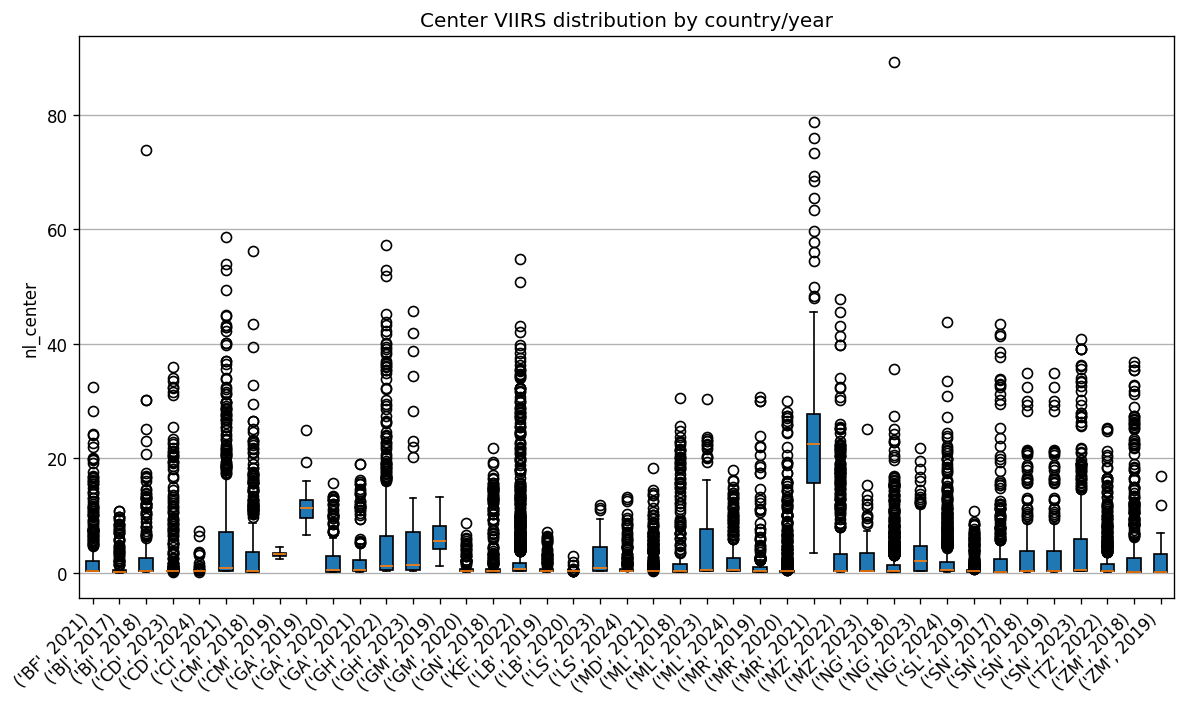

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_mean_by_country_year.png


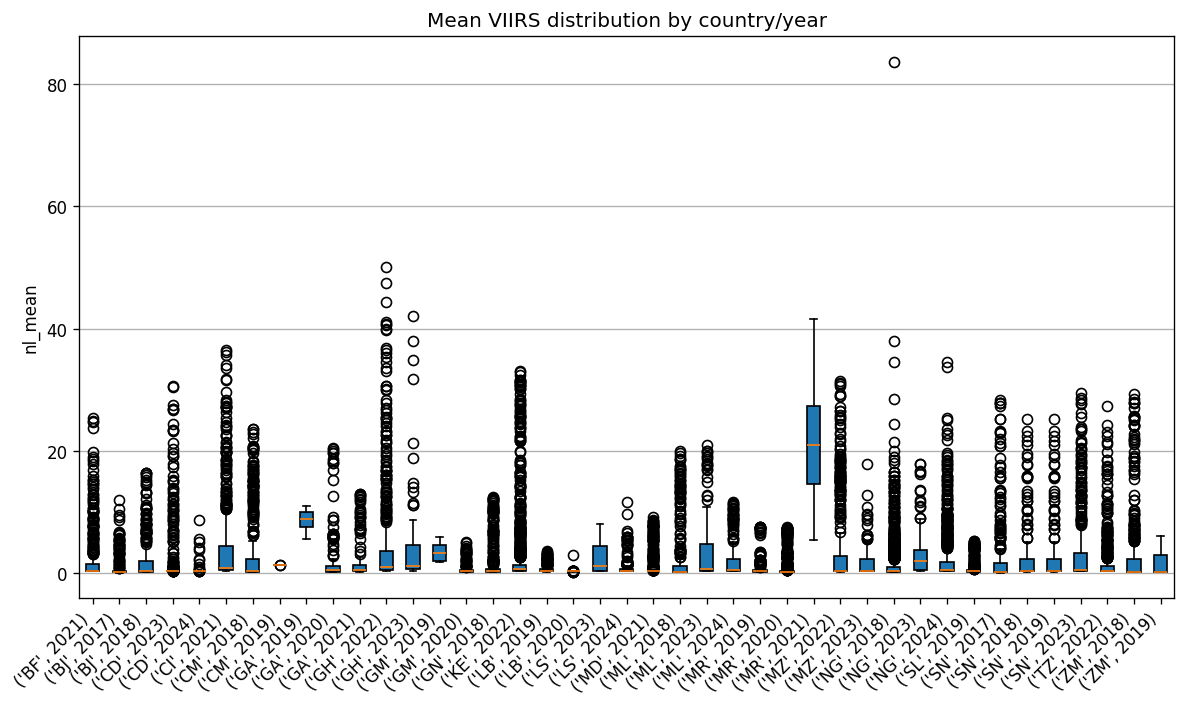

In [26]:
# ================================================
# 5.4) Nightlights distributions (VIIRS only)
# ================================================
viirs_mask = np.ones(len(df), dtype=bool)

boxplot_df(df[viirs_mask], 'nl_center', ['country','year'],
           fig_name="viirs_center_by_country_year.png",
           figsize=(10,6), ylabel='nl_center',
           title='Center VIIRS distribution by country/year')

boxplot_df(df[viirs_mask], 'nl_mean', ['country','year'],
           fig_name="viirs_mean_by_country_year.png",
           figsize=(10,6), ylabel='nl_mean',
           title='Mean VIIRS distribution by country/year')


share households < 16: 0.09204602301150576
Saved figure: /content/drive/MyDrive/Data Distribution/households_hist.png


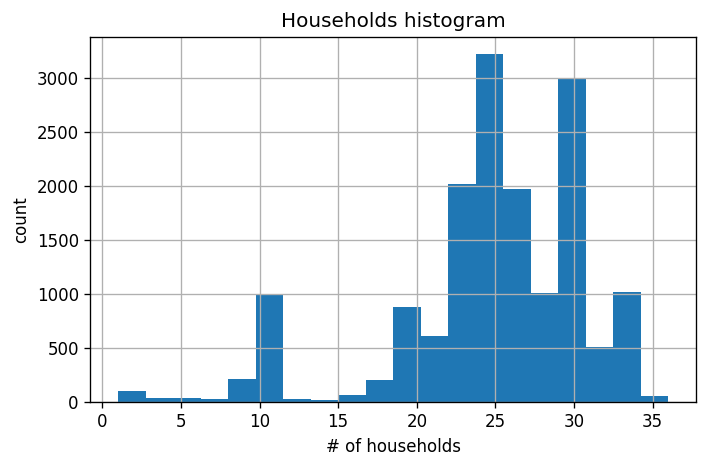

,count,mean,std,min,0%,1%,2%,3%,4%,5%,...,91%,92%,93%,94%,95%,96%,97%,98%,99%,max
households,15992.0,24.584542,6.281953,1.0,1.0,6.0,9.0,10.0,10.0,10.0,...,31.0,32.0,32.0,33.0,34.0,34.0,34.0,34.0,34.0,36.0


Saved figure: /content/drive/MyDrive/Data Distribution/households_by_country.png


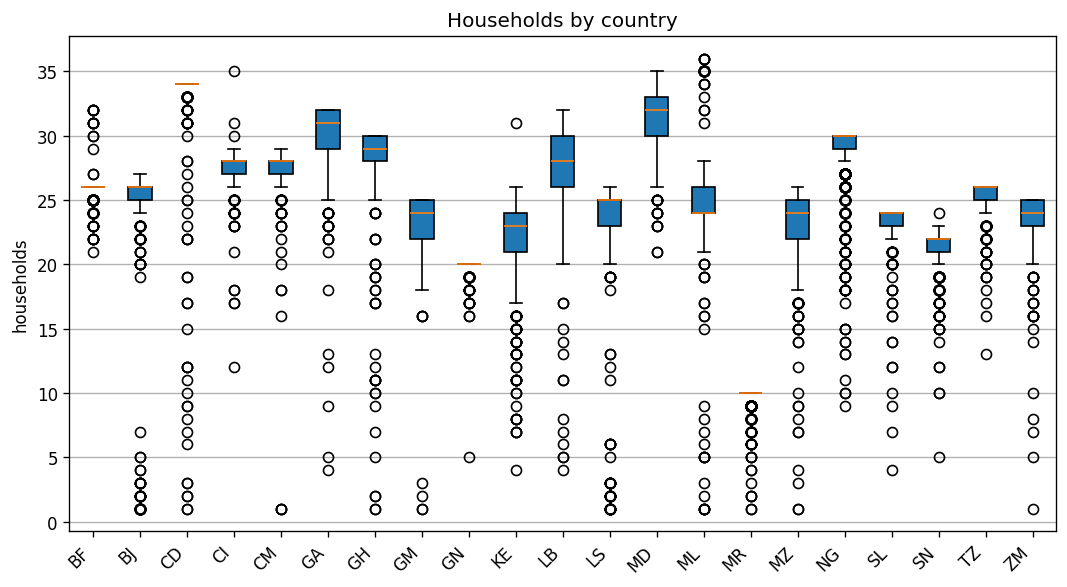

Saved figure: /content/drive/MyDrive/Data Distribution/households_by_year.png


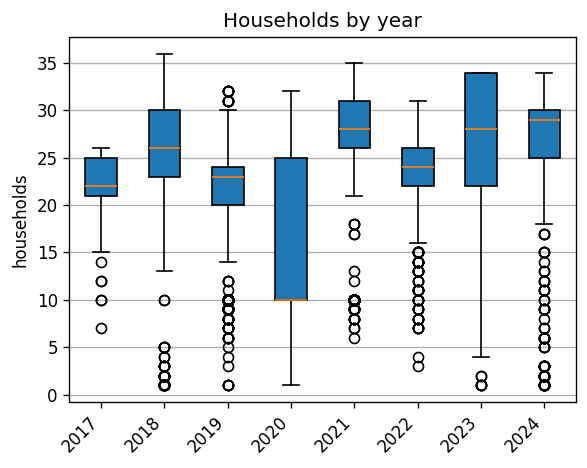

Saved figure: /content/drive/MyDrive/Data Distribution/households_by_country_year.png


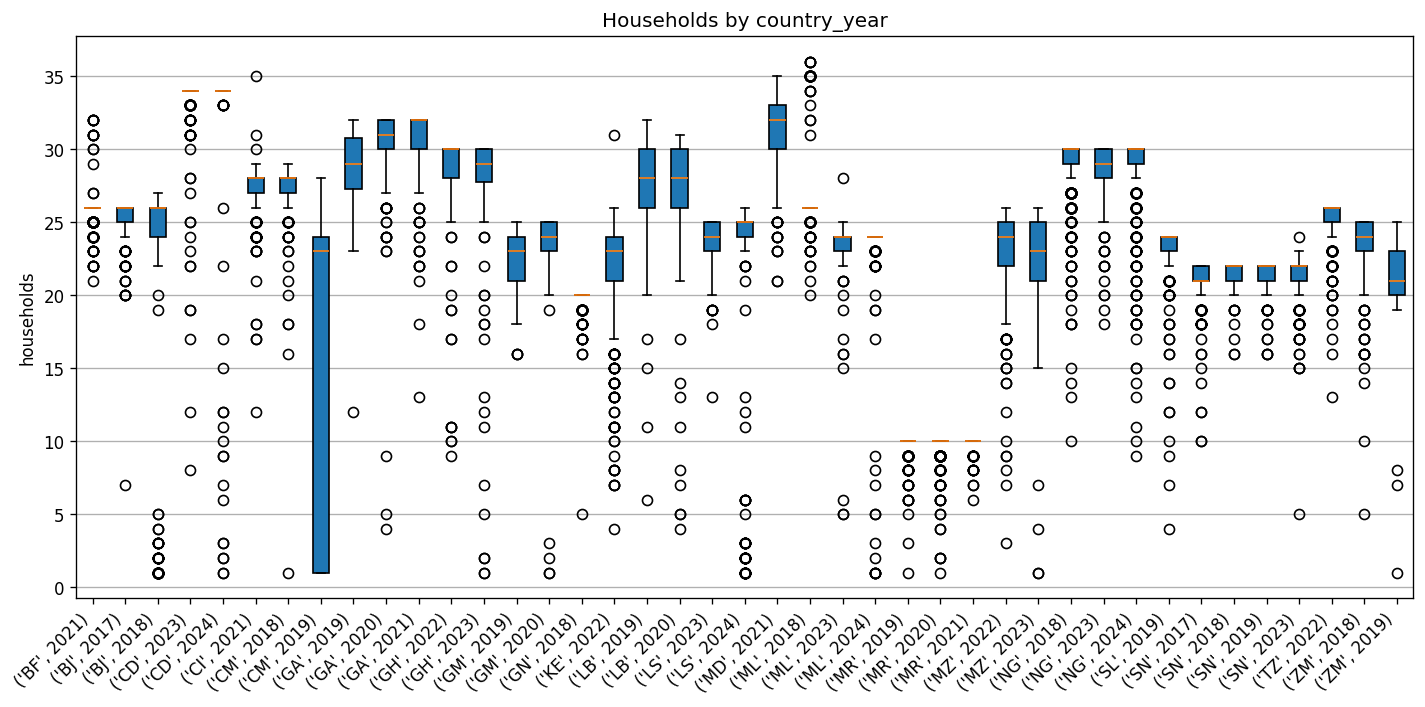

In [27]:
# ================================================
# 5.5) Households
# ================================================
print("share households < 16:", float((df['households']<16).mean()))

fig, ax = plt.subplots(1,1, figsize=(6,4))
df['households'].plot.hist(bins=20, grid=True, ax=ax)
_ = ax.set(xlabel='# of households', ylabel='count', title='Households histogram')
savefig_dd("households_hist.png")
plt.show()

display(df['households'].describe(percentiles=np.arange(0,1,0.01)).to_frame().T)

boxplot_df(df, 'households', 'country',
           fig_name="households_by_country.png",
           figsize=(9,5), ylabel='households', title='Households by country')

boxplot_df(df, 'households', 'year',
           fig_name="households_by_year.png",
           figsize=(5,4), ylabel='households', title='Households by year')

boxplot_df(df, 'households', ['country','year'],
           fig_name="households_by_country_year.png",
           figsize=(12,6), ylabel='households', title='Households by country_year')


Saved figure: /content/drive/MyDrive/Data Distribution/wealthpooled_by_fold_ooc.png


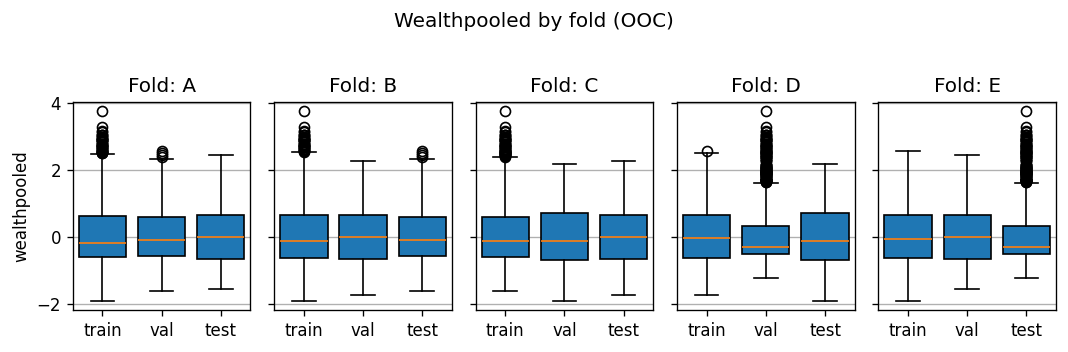

Saved figure: /content/drive/MyDrive/Data Distribution/wealthpooled_by_fold_incountry.png


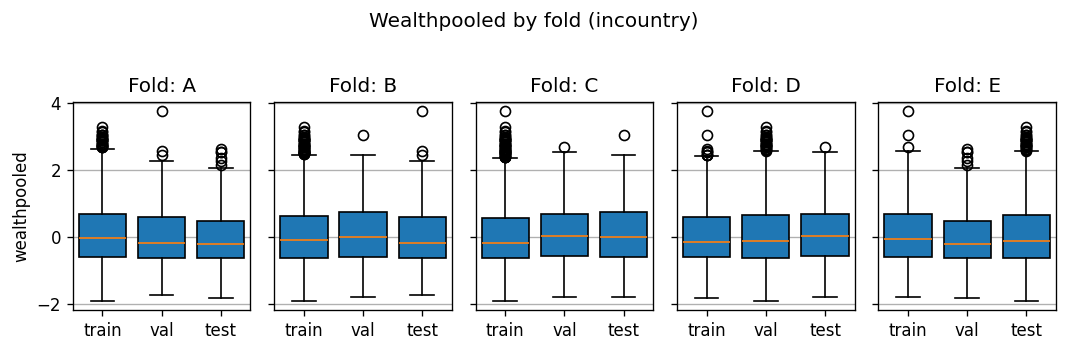

Saved figure: /content/drive/MyDrive/Data Distribution/urban_fraction_by_fold_ooc.png


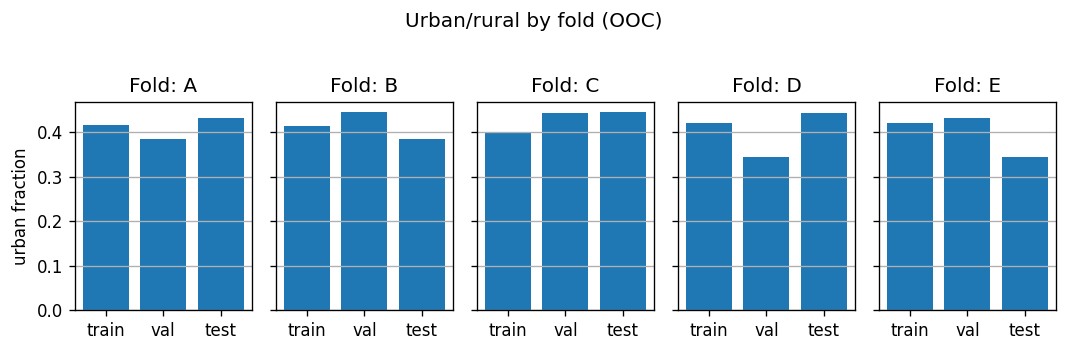

Saved figure: /content/drive/MyDrive/Data Distribution/urban_fraction_by_fold_incountry.png


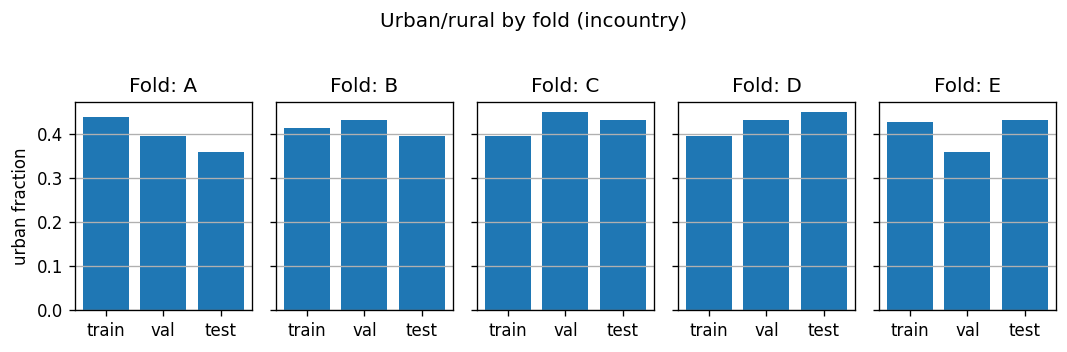

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_nl_mean_ooc.png


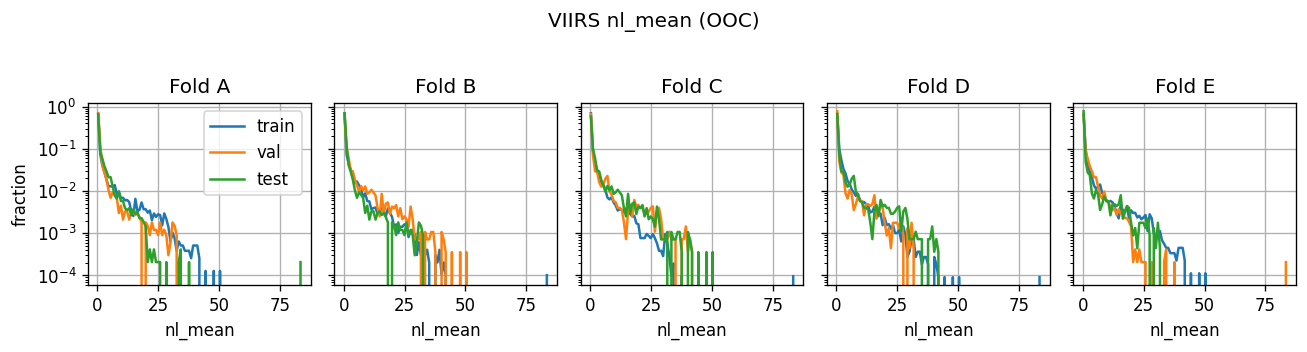

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_nl_mean_incountry.png


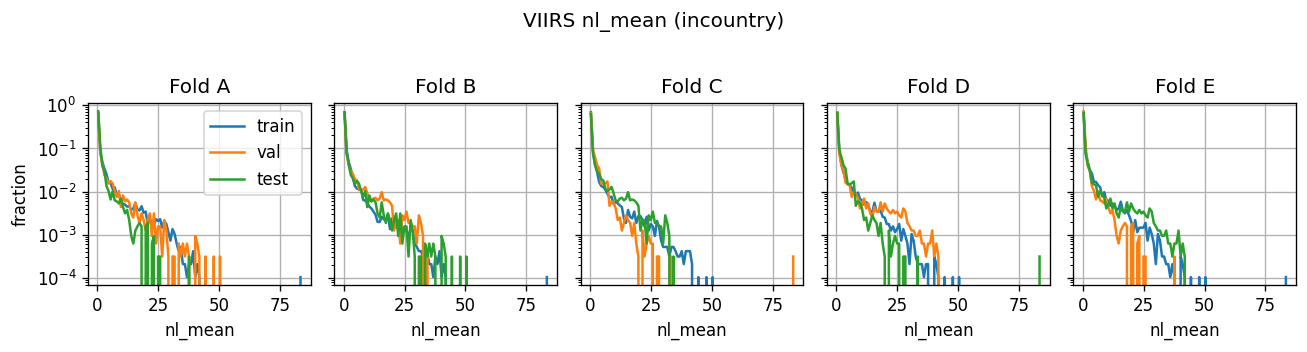

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_nl_center_ooc.png


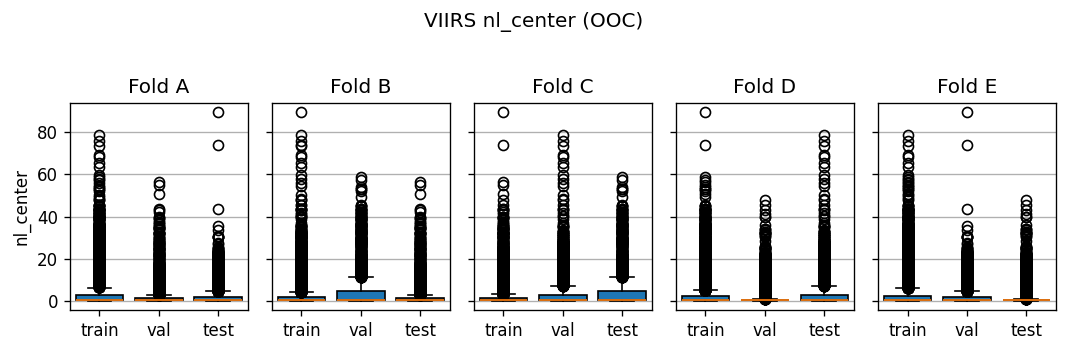

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_nl_center_incountry.png


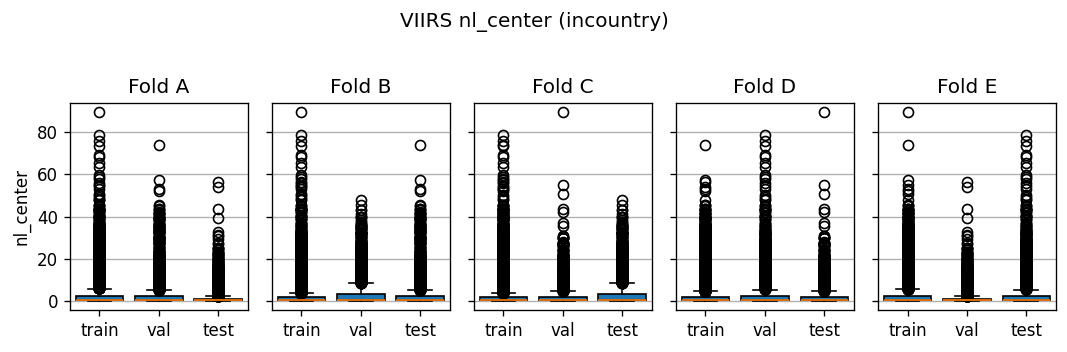

In [28]:
# ================================================
# 6) Data Analysis by Split
# ================================================
def plot_labels_by_fold(labels, folds, title, fig_name):
    fig, axs = plt.subplots(1,5, sharey=True, figsize=(9,2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = [labels[folds[f][split]] for split in SPLITS]
        ax.boxplot(data, patch_artist=True, widths=0.8)
        plt.setp(ax, xticks=[1,2,3], xticklabels=SPLITS)
        ax.grid(True, axis='y'); ax.set_title(f'Fold: {f}')
    axs[0].set_ylabel('wealthpooled')
    if title: fig.suptitle(title, y=1.03)
    savefig_dd(fig_name)
    plt.show()

plot_labels_by_fold(df['wealthpooled'].values, ooc_folds,
                    title='Wealthpooled by fold (OOC)',
                    fig_name="wealthpooled_by_fold_ooc.png")

plot_labels_by_fold(df['wealthpooled'].values, incountry_folds,
                    title='Wealthpooled by fold (incountry)',
                    fig_name="wealthpooled_by_fold_incountry.png")

def plot_urban_by_fold(urban, folds, title, fig_name):
    fig, axs = plt.subplots(1,5, sharey=True, figsize=(9,2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = [urban[folds[f][split]].mean() for split in SPLITS]
        ax.bar([0,1,2], data, width=0.8)
        plt.setp(ax, xticks=[0,1,2], xticklabels=SPLITS)
        ax.grid(True, axis='y'); ax.set_title(f'Fold: {f}')
    axs[0].set_ylabel('urban fraction')
    if title: fig.suptitle(title, y=1.03)
    savefig_dd(fig_name)
    plt.show()

plot_urban_by_fold(df['urban'].values.astype(float), ooc_folds,
                   title='Urban/rural by fold (OOC)',
                   fig_name="urban_fraction_by_fold_ooc.png")

plot_urban_by_fold(df['urban'].values.astype(float), incountry_folds,
                   title='Urban/rural by fold (incountry)',
                   fig_name="urban_fraction_by_fold_incountry.png")

DMSP_VIIRS_YEAR = 2012  # VIIRS >= 2012

def plot_nl_by_fold_viirs(df_in, folds, col, title, fig_name):
    fig, axs = plt.subplots(1, 5, sharey=True, figsize=(11, 2.8))
    bin_edges = np.linspace(df_in[col].min() - 0.1, df_in[col].max() + 0.1, 100)
    centers = np.convolve(bin_edges, [.5, .5], mode='valid')
    for f, ax in zip(FOLDS, axs.flat):
        for split in SPLITS:
            idx = folds[f][split]
            sub = df_in.loc[idx, [col, 'year']]
            vals = sub.loc[sub['year'] >= DMSP_VIIRS_YEAR, col].values
            if vals.size == 0:
                continue
            hist, _ = np.histogram(vals, bins=bin_edges)
            if hist.sum() > 0:
                ax.plot(centers, hist / hist.sum(), label=split)
        ax.set_xlabel(col); ax.set_yscale('log'); ax.set_title(f'Fold {f}'); ax.grid(True)
    axs[0].legend(); axs[0].set_ylabel('fraction')
    if title: fig.suptitle(title, y=1.03)
    savefig_dd(fig_name)
    plt.show()

def nl_boxplots_by_fold_viirs(df_in, folds, col, title, fig_name):
    fig, axs = plt.subplots(1, 5, sharey=True, figsize=(9, 2.8))
    for f, ax in zip(FOLDS, axs.flat):
        data = []
        for split in SPLITS:
            idx = folds[f][split]
            sub = df_in.loc[idx, [col, 'year']]
            vals = sub.loc[sub['year'] >= DMSP_VIIRS_YEAR, col].values
            data.append(vals)
        ax.boxplot(data, patch_artist=True, widths=0.8)
        plt.setp(ax, xticks=[1, 2, 3], xticklabels=SPLITS)
        ax.set_title(f'Fold {f}'); ax.grid(True, axis='y')
    axs[0].set_ylabel(col)
    if title: fig.suptitle(title, y=1.03)
    savefig_dd(fig_name)
    plt.show()

plot_nl_by_fold_viirs(df, ooc_folds,       'nl_mean',   'VIIRS nl_mean (OOC)',       "viirs_nl_mean_ooc.png")
plot_nl_by_fold_viirs(df, incountry_folds, 'nl_mean',   'VIIRS nl_mean (incountry)', "viirs_nl_mean_incountry.png")
nl_boxplots_by_fold_viirs(df, ooc_folds,       'nl_center', 'VIIRS nl_center (OOC)',     "viirs_nl_center_ooc.png")
nl_boxplots_by_fold_viirs(df, incountry_folds, 'nl_center', 'VIIRS nl_center (incountry)', "viirs_nl_center_incountry.png")


,VIIRS
True 0,0.051388171
min nls_center,0.032805849
min nls_mean,0.051388171


,count,mean,std,min,25%,50%,75%,max
label_when_VIIRS_is_all_zero,1.0,-0.862743,NaN,-0.862743,-0.862743,-0.862743,-0.862743,-0.862743


Saved figure: /content/drive/MyDrive/Data Distribution/viirs_all_zero_hist.png


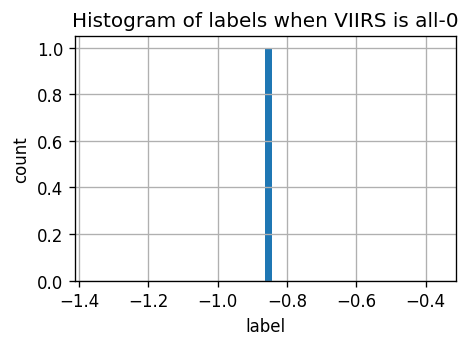

Saved figure: /content/drive/MyDrive/Data Distribution/viirs_all_zero_by_country.png


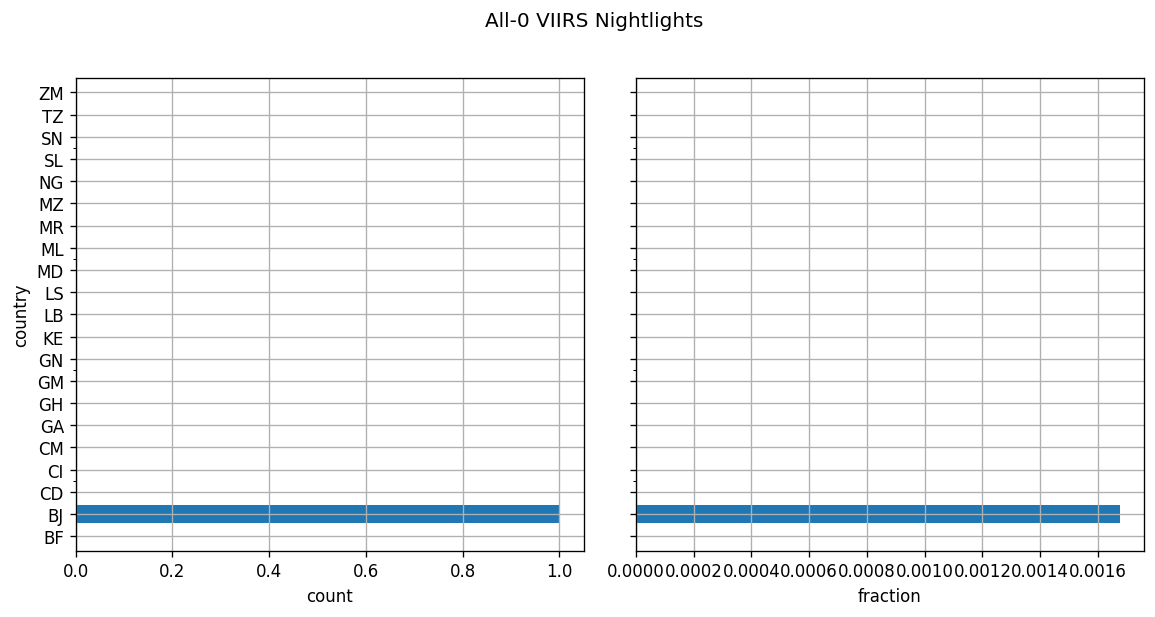

In [29]:
# ================================================
# 7) All-Zero VIIRS NL check
# ================================================
viirs_mask = np.ones(len(df), dtype=bool)
VIIRS_ZERO = float(df.loc[viirs_mask, 'nl_mean'].min())

zeros_df = pd.DataFrame(
    {
        'VIIRS': [
            VIIRS_ZERO,
            df.loc[viirs_mask, 'nl_center'].min(),
            df.loc[viirs_mask, 'nl_mean'].min(),
        ],
    },
    index=['True 0', 'min nls_center', 'min nls_mean']
)

with pd.option_context('display.precision', 9):
    display(zeros_df)

viirs_zero_mask = viirs_mask & (df['nl_mean'].values == VIIRS_ZERO)

zeros_label_df = pd.DataFrame(
    {'label_when_VIIRS_is_all_zero': df['wealthpooled'].values[viirs_zero_mask]}
)
display(zeros_label_df.describe().T)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
ax.hist(df['wealthpooled'].values[viirs_zero_mask], bins=50)
ax.set(xlabel='label', ylabel='count', title='Histogram of labels when VIIRS is all-0')
ax.grid(True)
savefig_dd("viirs_all_zero_hist.png")
plt.show()

df['zero_nl_viirs'] = viirs_zero_mask
zero_nl_counts = df.groupby('country')['zero_nl_viirs'].sum().astype(int)
zero_nl_frac   = zero_nl_counts / df.groupby('country').size()

fig, axs = plt.subplots(1, 2, sharey=True, figsize=(10, 5))
zero_nl_counts.plot.barh(width=0.8, ax=axs[0], grid=True)
zero_nl_frac.plot.barh(width=0.8, ax=axs[1], grid=True)
axs[0].set_xlabel('count')
axs[1].set_xlabel('fraction')
fig.suptitle('All-0 VIIRS Nightlights', y=1.02)
savefig_dd("viirs_all_zero_by_country.png")
plt.show()


In [30]:
# ================================================
# 8) Visualize Images (per-band panels) — robust key→path lookup
# 8.1) Highest wealth; 8.2) Lowest wealth
# ================================================
with tf.io.gfile.GFile(LOC_DICT_PATH, "rb") as f:
    loc_dict_v = pickle.load(f)

ldf_v = pd.DataFrame(
    [{"country":k[0], "tf_year":k[1], "cluster":k[2], **v} for k,v in loc_dict_v.items()]
)
ldf_key = ldf_v[["lat","lon","svyid_year","cluster","tf_year"]].copy()
ldf_key["lat"]  = ldf_key["lat"].astype(float)
ldf_key["lon"]  = ldf_key["lon"].astype(float)
ldf_key["svyid_year"] = ldf_key["svyid_year"].astype(int)

df_aug = df.copy()
df_aug["lat"]  = df_aug["lat"].astype(float)
df_aug["lon"]  = df_aug["lon"].astype(float)
df_aug["year"] = df_aug["year"].astype(int)

merged_df = df_aug.merge(
    ldf_key, left_on=["lat","lon","year"], right_on=["lat","lon","svyid_year"],
    how="left", validate="one_to_one"
)
if merged_df["cluster"].isna().any():
    nmiss = int(merged_df["cluster"].isna().sum())
    raise AssertionError(f"{nmiss} rows could not be matched to cluster/tf_year via (lat,lon,svyid_year).")

merged_df["tf_key"] = list(zip(merged_df["country"].astype(str),
                               merged_df["tf_year"].astype(int),
                               merged_df["cluster"].astype(int)))

def iter_examples_tfrecord(path):
    ds = tf.data.TFRecordDataset(path, compression_type="GZIP")
    for raw in ds.as_numpy_iterator():
        yield tf.train.Example.FromString(raw)

def _as_int(f, k):
    if k in f and f[k].int64_list.value:
        return int(f[k].int64_list.value[0])
    if k in f and f[k].float_list.value:
        return int(f[k].float_list.value[0])
    return None

def _as_str(f, k):
    if k in f and f[k].bytes_list.value:
        return f[k].bytes_list.value[0].decode("utf-8")
    return None

def build_keymap(glob_pat):
    key_to_path = {}
    file_paths = sorted(tf.io.gfile.glob(glob_pat))
    assert file_paths, f"No TFRecords match: {glob_pat}"
    for p in tqdm(file_paths, desc="Index TFRecords"):
        for ex in iter_examples_tfrecord(p):
            f = ex.features.feature
            cc  = (_as_str(f,"country") or "").upper()[:2]
            yr  = _as_int(f,"year")
            clu = _as_int(f,"cluster_index") if "cluster_index" in f else _as_int(f,"cluster")
            if not cc or yr is None or clu is None:
                continue
            key = (cc, int(yr), int(clu))
            key_to_path.setdefault(key, p)
    return key_to_path

if tf.io.gfile.exists(KEYMAP_PKL):
    with tf.io.gfile.GFile(KEYMAP_PKL, "rb") as f:
        key_to_path = pickle.load(f)
else:
    key_to_path = build_keymap(TFRECORD_GLOB)
    with tf.io.gfile.GFile(KEYMAP_PKL, "wb") as f:
        pickle.dump(key_to_path, f)
print("Keymap entries:", len(key_to_path))
print("Saved/used keymap:", KEYMAP_PKL)

def _as_arr(f, k):
    return np.asarray(f[k].float_list.value, dtype=np.float32) if k in f else None

def _center_crop(arr, patch=PATCH, crop=CROP):
    if arr is None or arr.size != patch*patch:
        return None
    z = arr.reshape(patch, patch)
    s = (patch - crop) // 2
    return z[s:s+crop, s:s+crop].ravel()

def fetch_image_for_key(key):
    if key not in key_to_path:
        return None
    p = key_to_path[key]
    for ex in iter_examples_tfrecord(p):
        f = ex.features.feature
        cc  = (_as_str(f,"country") or "").upper()[:2]
        yr  = _as_int(f,"year")
        clu = _as_int(f,"cluster_index") if "cluster_index" in f else _as_int(f,"cluster")
        if (cc, int(yr), int(clu)) != key:
            continue
        chans = []
        for b in BANDS_ALL:
            a = _as_arr(f, b)
            a = _center_crop(a, patch=PATCH, crop=CROP)
            if a is None:
                chans.append(np.zeros((CROP*CROP,), dtype=np.float32))
            else:
                chans.append(a)
        arr = np.stack(chans, axis=-1).reshape(CROP, CROP, len(BANDS_ALL))
        return arr
    return None

def plot_image_by_band(img, band_order, nrows=1, title=None, save_name=None):
    k = len(band_order)
    ncols = k if nrows==1 else int(math.ceil(k/nrows))
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.8*ncols, 1.8*nrows))
    axes = np.atleast_1d(axes).ravel()
    for i, b in enumerate(band_order):
        chan = img[:, :, BANDS_ALL.index(b)]
        axes[i].imshow(chan)
        axes[i].set_title(b, fontsize=8)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    if title: fig.suptitle(title)
    if save_name: savefig_dd(save_name)
    plt.show()

labels = merged_df["wealthpooled"].values
K = 5

# Highest wealth
top_rows = np.argsort(labels)[::-1][:K]
for k, ridx in enumerate(top_rows, start=1):
    r = merged_df.iloc[int(ridx)]
    key = (str(r["country"]), int(r["tf_year"]), int(r["cluster"]))
    img = fetch_image_for_key(key)
    if img is None:
        print(f"[skip] {key} not found in TFRecords")
        continue
    title = f"{k}-th highest wealth: {r['wealthpooled']:.06f}, loc = {r['country']} {int(r['tf_year'])} ({float(r['lat']):.06f}, {float(r['lon']):.06f})"
    plot_image_by_band(img, BAND_ORDER, nrows=1, title=title, save_name=f"panel_high_{k}.png")

# Lowest wealth
low_rows = np.argsort(labels)[:K]
for k, ridx in enumerate(low_rows, start=1):
    r = merged_df.iloc[int(ridx)]
    key = (str(r["country"]), int(r["tf_year"]), int(r["cluster"]))
    img = fetch_image_for_key(key)
    if img is None:
        print(f"[skip] {key} not found in TFRecords")
        continue
    title = f"{k}-th lowest wealth: {r['wealthpooled']:.06f}, loc = {r['country']} {int(r['tf_year'])} ({float(r['lat']):.06f}, {float(r['lon']):.06f})"
    plot_image_by_band(img, BAND_ORDER, nrows=1, title=title, save_name=f"panel_low_{k}.png")


Output hidden; open in https://colab.research.google.com to view.